In [1]:
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from tqdm import tqdm
import itertools

In [2]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import networkx as nx

# Underlying Graph + Data Generation

In [3]:
# Generate data from an underlying graph
class TrueGraph:
    def __init__(self, n, factors, alphabet_size=2):
        """
        Store a factor graph along with mechanisms to generate data.

        Parameters
        ----------
        n : int
            Number of variables.
        factors : list of (list[int], callable)
            Each element is a tuple:
              - scope : list[int]   -- variable indices involved in this factor
              - f     : callable    -- function f(*values) -> float (unnormalized
                                       factor value; need not be a probability).
                                       Values are passed in the order given by scope.
        alphabet_size : int or list[int]
            If int, every variable takes values in {0, ..., alphabet_size-1}.
            If list, alphabet_size[i] is the number of values variable i can take.
        """
        self.n = n
        self.factors = factors  # list of (scope, func)

        # Normalize alphabet_size to a per-variable list
        if isinstance(alphabet_size, int):
            self.alphabet_sizes = [alphabet_size] * n
        else:
            if len(alphabet_size) != n:
                raise ValueError("len(alphabet_size) must equal n")
            self.alphabet_sizes = list(alphabet_size)

        # Precompute: for each variable i, which factors involve it?
        self._var_to_factors = [[] for _ in range(n)]
        for k, (scope, _) in enumerate(factors):
            for i in scope:
                self._var_to_factors[i].append(k)

    def _log_factor_value(self, factor_idx, state):
        """
        Evaluate log of factor k given current state (length-n int array).
        Returns -inf if the factor value is <= 0.
        """
        scope, f = self.factors[factor_idx]
        val = f(*[state[i] for i in scope])
        if val <= 0:
            return -np.inf
        return np.log(val)
 
    def _conditional_log_probs(self, var_idx, state):
        """
        Compute the (unnormalized) log conditional distribution of variable
        var_idx given all other variables fixed to state.
 
        Only factors that involve var_idx need to be evaluated because all
        others are constant with respect to x_{var_idx}.
 
        Returns
        -------
        log_probs : np.ndarray, shape (alphabet_sizes[var_idx],)
            Unnormalized log probabilities for each possible value.
        """
        a = self.alphabet_sizes[var_idx]
        log_probs = np.zeros(a)
        relevant_factors = self._var_to_factors[var_idx]
 
        for v in range(a):
            state[var_idx] = v  # temporarily set
            for k in relevant_factors:
                log_probs[v] += self._log_factor_value(k, state)
 
        return log_probs
 
    def _log_probs_to_probs(self, log_probs):
        """Numerically stable softmax (shift by max before exp)."""
        lp = log_probs - np.max(log_probs)
        p = np.exp(lp)
        p /= p.sum()
        return p

    def factor_value(self, state):
        log_total = 0
        for idx in range(len(self.factors)):
            log_total += self._log_factor_value(idx, state)
        return np.exp(log_total)

    def sample(self, nsamples, n_burnin=1000, thinning=10, seed=None, progress=True):
        """
        Draw samples via Gibbs sampling.
 
        Parameters
        ----------
        nsamples : int
            Number of samples to return.
        n_burnin : int
            Number of Gibbs sweeps to discard before collecting samples.
        thinning : int
            Collect one sample every `thinning` sweeps to reduce
            autocorrelation.
        seed : int or None
 
        Returns
        -------
        np.ndarray, shape (nsamples, n), dtype int
            Each row is one sample; values are in {0, ..., alphabet_size_i - 1}.
        """
        rng = np.random.default_rng(seed)
 
        # Initialise state randomly
        state = np.array(
            [rng.integers(0, self.alphabet_sizes[i]) for i in range(self.n)],
            dtype=int,
        )
 
        def gibbs_sweep():
            for i in range(self.n):
                log_probs = self._conditional_log_probs(i, state)
                probs = self._log_probs_to_probs(log_probs)
                state[i] = rng.choice(self.alphabet_sizes[i], p=probs)
 
        # Burn-in
        for _ in range(n_burnin):
            gibbs_sweep()
 
        # Collect samples
        samples = np.zeros((nsamples, self.n), dtype=int)
        for s in tqdm(range(nsamples), disable = not progress):
            for _ in range(thinning):
                gibbs_sweep()
            samples[s] = state.copy()
 
        return samples

    def edge_set(self):
        edgeset = set()
        for scope, f in self.factors:
            if len(scope) < 2:
                continue
            for i in range(len(scope)):
                for j in range(i+1,len(scope)):
                    pair = (scope[i], scope[j])
                    pair_flip = (scope[j], scope[i])
                    if pair not in edgeset and pair_flip not in edgeset:
                        edgeset.add(pair)
        return edgeset

    def adjacency_list(self):
        adj_list = [[] for _ in range(self.n)]
        edgeset = self.edge_set()
        for i, j in edgeset:
            adj_list[i].append(j)
            adj_list[j].append(i)
        return adj_list
 
    def display_graph(self, var_names=None, factor_labels=None, ax=None,
                      figsize=(8, 6), seed=None):
        """
        Draw the factor graph using networkx and matplotlib.
 
        Variable nodes are drawn as circles; factor nodes as squares.
        Edges connect each factor to the variables in its scope.
 
        Parameters
        ----------
        var_names : list[str] or None
            Labels for variable nodes.  Defaults to ["x0", "x1", ...].
        factor_labels : list[str] or None
            Labels for factor nodes.  Defaults to ["f0", "f1", ...].
        ax : matplotlib Axes or None
            If None, a new figure is created.
        figsize : tuple
            Figure size (only used if ax is None).
        seed : int or None
            Layout seed for reproducibility.
 
        Returns
        -------
        fig, ax
        """
        if var_names is None:
            var_names = [f"x{i}" for i in range(self.n)]
        if factor_labels is None:
            factor_labels = [f"f{k}" for k in range(len(self.factors))]
 
        # Build bipartite graph
        G = nx.Graph()
 
        var_nodes = [f"var_{i}" for i in range(self.n)]
        fac_nodes = [f"fac_{k}" for k in range(len(self.factors))]
 
        G.add_nodes_from(var_nodes, bipartite=0)
        G.add_nodes_from(fac_nodes, bipartite=1)
 
        for k, (scope, _) in enumerate(self.factors):
            for i in scope:
                G.add_edge(f"fac_{k}", f"var_{i}")
 
        # Layout
        pos = nx.spring_layout(G, seed=seed)
 
        if ax is None:
            fig, ax = plt.subplots(figsize=figsize)
        else:
            fig = ax.get_figure()
 
        ax.set_aspect("equal")
        ax.axis("off")
 
        # Draw variable nodes (circles)
        nx.draw_networkx_nodes(
            G, pos,
            nodelist=var_nodes,
            node_shape="o",
            node_color="#4C9BE8",
            node_size=900,
            ax=ax,
        )
        # Draw factor nodes (squares)
        nx.draw_networkx_nodes(
            G, pos,
            nodelist=fac_nodes,
            node_shape="s",
            node_color="#F4A442",
            node_size=700,
            ax=ax,
        )
        # Edges
        nx.draw_networkx_edges(G, pos, width=1.8, alpha=0.7, edge_color="#555555", ax=ax)
 
        # Labels
        var_label_map = {f"var_{i}": var_names[i] for i in range(self.n)}
        fac_label_map = {f"fac_{k}": factor_labels[k] for k in range(len(self.factors))}
        label_map = {**var_label_map, **fac_label_map}
 
        nx.draw_networkx_labels(
            G, pos, labels=label_map,
            font_size=10, font_color="white", font_weight="bold",
            ax=ax,
        )
 
        # Legend
        legend_handles = [
            mpatches.Patch(color="#4C9BE8", label="Variable node"),
            mpatches.Patch(color="#F4A442", label="Factor node"),
        ]
        ax.legend(handles=legend_handles, loc="best", framealpha=0.9)
        ax.set_title("Factor Graph", fontsize=13, fontweight="bold")
 
        fig.tight_layout()
        return fig, ax

# Helpers

In [4]:
def one_hot_encode(data: np.ndarray, alphabet_size: int) -> np.ndarray:
    """
    Parameters
    ----------
    data : (N, n_vars) integer array
    alphabet_size : int

    Returns
    -------
    (N, n_vars * alphabet_size) float32 array
    """
    N, n_vars = data.shape
    out = np.zeros((N, n_vars * alphabet_size), dtype=np.float32)
    for i in range(n_vars):
        out[np.arange(N), i * alphabet_size + data[:, i]] = 1.0
    return out

def to_network_input(data: np.ndarray, one_hot: bool, alphabet_size: int) -> torch.Tensor:
    """Convert integer-coded data array to the float tensor the network expects."""
    if one_hot:
        arr = one_hot_encode(data, alphabet_size)
    else:
        arr = data.astype(np.float32)
    return torch.tensor(arr, dtype=torch.float32)

# Noise Generator

In [5]:
class IndependentMarginals:
    def __init__(self, data, alphabet_size, alpha = 0.1, seed=123):
        N, n_vars = data.shape
        self.n_vars = n_vars
        self.alphabet_size = alphabet_size
        self.rng = np.random.default_rng(seed=seed)

        # compute marginals
        self.marginal_probs = np.zeros((n_vars,alphabet_size))
        for i in range(n_vars):
            for j in range(alphabet_size):
                self.marginal_probs[i,j] = np.sum(data[:,i] == j)
        self.marginal_probs += alpha
        self.marginal_probs /= self.marginal_probs.sum(axis=1, keepdims=True)

    def generate_samples(self, n_samples):
        samples = np.zeros((n_samples, self.n_vars), dtype=int)
        for i in range(self.n_vars):
            samples[:,i] = self.rng.choice(self.alphabet_size, size = n_samples, p = self.marginal_probs[i,:])
        return samples

    def log_prob(self, data):
        # data has shape (N, n_vars)
        log_q = np.zeros(data.shape[0])
        for i in range(self.n_vars):
            log_q += np.log(self.marginal_probs[i,data[:,i]])
        return log_q

# Structure Learning Neural Network

In [250]:
class FactorGraphNetwork(nn.Module):
    def __init__(self, n_vars, alphabet_size, K, hidden_dims=(16,16), max_factor_size=None, shared_mlp=False, seed=None):
        super().__init__()

        if seed is not None:
            torch.manual_seed(seed)
            np.random.seed(seed)
        
        self.n_vars = n_vars
        self.alphabet_size = alphabet_size
        self.K = K
        self.max_factor_size = max_factor_size
        self.shared_mlp = shared_mlp
        
        # specify input dimension; just = number variables if discrete binary or continuous
        if alphabet_size <= 2:
            self.input_dim = n_vars
            self.one_hot = False
        else:
            self.input_dim = n_vars * alphabet_size
            self.one_hot = True

        # variable masks
        self.raw_masks = nn.Parameter(0.1 * torch.randn(K, n_vars))

        # input to factor Multilayer Perceptrons
        def build_mlp(in_dim, hidden_dims):
            layers = []
            prev = in_dim
            for h in hidden_dims:
                layers += [nn.Linear(prev, h), nn.ReLU()]
                prev = h
            layers.append(nn.Linear(prev, 1))
            return nn.Sequential(*layers)

        if shared_mlp:
            self.mlp = build_mlp(self.input_dim, hidden_dims)
        else:
            self.mlps = nn.ModuleList(
                [build_mlp(self.input_dim, hidden_dims) for _ in range(K)]
            )

        # factor weights
        self.raw_weights = nn.Parameter(0.1 * torch.randn(K))

    def soft_masks(self):
        return torch.sigmoid(self.raw_masks)

    def soft_weights(self):
        return torch.sigmoid(self.raw_weights)

    def masks(self, threshold=0.3):
        # soft mask
        mask_soft = self.soft_masks()  # (K, n_vars)
        # hard mask (0 or 1)
        if self.max_factor_size is not None:
            K, n_vars = mask_soft.shape
            k = min(self.max_factor_size, n_vars)
            # get top-k indices per factor
            topk_vals, topk_idx = torch.topk(mask_soft, k=k, dim=1)
            # build top-k mask
            topk_mask = torch.zeros_like(mask_soft)
            topk_mask.scatter_(1, topk_idx, 1.0)
            # threshold condition
            thresh_mask = (mask_soft > threshold).float()
            # combine both conditions
            mask_hard = topk_mask * thresh_mask
        else:
            # no max factor size
            mask_hard = (mask_soft > threshold).float()
        # straight-through estimator
        mask = mask_hard.detach() + mask_soft - mask_soft.detach()
        return mask

    def weights(self, threshold=0.3):
        # soft mask
        weight_soft = self.soft_weights()
        # hard mask (0 or 1)
        weight_hard = (weight_soft > threshold).float()
        # straight-through estimator
        weight = weight_hard.detach() + weight_soft - weight_soft.detach()
        return weight

    def _apply_mask(self, x: torch.Tensor, mask_k: torch.Tensor) -> torch.Tensor:
        if self.one_hot:
            mask_expanded = mask_k.repeat_interleave(self.alphabet_size)
        else:
            mask_expanded = mask_k
        return x * mask_expanded.unsqueeze(0)

    def forward(self, x):
        masks = self.masks() 
        weights = self.weights()

        factor_values = []  
        for k in range(self.K):
            x_masked = self._apply_mask(x, masks[k])
            mlp = self.mlp if self.shared_mlp else self.mlps[k]
            h_k = mlp(x_masked).squeeze(-1)            # (batch,)
            factor_values.append(h_k)

        # Stack: (batch, K)
        H = torch.stack(factor_values, dim=1)
        # Stage 2: weighted sum  ->  (batch,)
        output = (H * weights.unsqueeze(0)).sum(dim=1)
        return output

    def regularization_loss(self, lambda_mask=0.1, lambda_weight=0.1, lambda_mlp_l2=0, lambda_bp=0):
        masks = self.masks()
        weights = self.weights()
        # mask penalty
        mask_reg = masks.mean()
        # weight penalty
        weight_reg = weights.mean()
        # L2 MLP weight penalty
        mlp_l2 = 0.0
        count = 0
        for p in self.parameters():
            if p.requires_grad and p is not self.raw_masks and p is not self.raw_weights:
                mlp_l2 += (p**2).sum()  
                count += p.numel()
        mlp_l2 /= count
        # Message passing penalty
        soft_masks = self.soft_masks()
        soft_weights = self.soft_weights()
        # sizes = masks.sum(dim=1)
        sizes = soft_masks.sum(dim=1)
        log_q = np.log(self.alphabet_size) # for stability
        msg_cost = torch.exp(log_q * sizes)
        # msg_penalty = (weights * sizes * msg_cost).mean()
        msg_penalty = (soft_weights * sizes * msg_cost).mean()
        return lambda_mask * mask_reg + lambda_weight * weight_reg + lambda_mlp_l2 * mlp_l2 + lambda_bp * msg_penalty

    def avg_factor_size(self):
        weights = self.weights()
        masks = self.masks()
        factor_sizes = masks.sum(dim=1)
        active = (weights == 1) & (factor_sizes > 0)
        if active.sum() == 0:
            return torch.tensor(0.0, device=weights.device)
        return factor_sizes[active].mean()

    def n_active_factors(self):
        weights = self.weights()
        masks = self.masks()
        factor_sizes = masks.sum(dim=1)
        active = (weights == 1) & (factor_sizes > 0)
        return active.sum()

# Model class with full capabilities

In [224]:
class FactorGraphLearner:
    def __init__(self, n_vars, alphabet_size, K, noise_generator, hidden_dims=(16,16), max_factor_size=None, shared_mlp=False, seed=None):
        self.network = FactorGraphNetwork(n_vars, alphabet_size, K, hidden_dims, max_factor_size, shared_mlp, seed=seed)
        self.noise_generator = noise_generator

    def nce_loss(self, x_real, x_fake, log_q_real, log_q_fake):
        model = self.network
        s_real = model(x_real) - log_q_real
        s_fake = model(x_fake) - log_q_fake
        logits = torch.cat([s_real, s_fake], dim=0)
        labels = torch.cat([torch.ones_like(s_real), torch.zeros_like(s_fake)], dim=0)
        return nn.functional.binary_cross_entropy_with_logits(logits, labels)

    def scale_penalty(self, base_lambda, epoch, max_epochs, schedule=True, start=0.1, end=0.5):
        # linear scaling of lambda penalty
        if not schedule:
            return base_lambda
        if start <= 1:
            start = int(start * max_epochs)
        if end <= 1:
            end = int(end * max_epochs)
        if epoch <= start:
            return 0
        elif epoch > end:
            return base_lambda
        else:
            return base_lambda * (epoch - start) / (end - start)

    def scale_all_penalties(self, epoch, max_epochs, lambda_mask, lambda_weight, lambda_bp, schedule=True, start=0.1, end=0.5):
        l_mask = self.scale_penalty(lambda_mask, epoch, max_epochs, schedule, start, end)
        l_wt = self.scale_penalty(lambda_weight, epoch, max_epochs, schedule, start, end)
        l_bp = self.scale_penalty(lambda_bp, epoch, max_epochs, schedule, start, end)
        return l_mask, l_wt, l_bp
        

    def train(self, data, n_epochs = 1000, batch_size = 128, lr = 1e-3, 
              lambda_mask = 0.1, lambda_weight = 0.1, lambda_mlp_l2 = 0.01, lambda_bp = 0.01, penalty_schedule=False,
              noise_ratio = 1, device = "cpu", verbose = True, log_every = 50):
        # train network using NCE
        model = self.network.to(device)
        optimizer = optim.Adam(model.parameters(), lr=lr)

        # real data - one hot encodings and log q
        x_real = to_network_input(data, model.one_hot, model.alphabet_size).to(device)
        log_q_real = torch.tensor(self.noise_generator.log_prob(data), dtype=torch.float32)

        # dataset
        dataset = TensorDataset(x_real, log_q_real)
        loader = DataLoader(dataset, batch_size=batch_size, shuffle=True)

        losses = {x : [] for x in ['Total', 'Main', 'Reg']}
        diagnostics = {x : [] for x in ["avg_factor_size", "n_active_factors"]}
        for epoch in range(n_epochs):
            epoch_loss = 0.0
            epoch_loss_main = 0.0
            epoch_loss_reg = 0.0
            for x_batch, lq_batch in loader:
                x_batch = x_batch.to(device)
                lq_batch = lq_batch.to(device)
                bn = x_batch.shape[0]

                # sample fake data
                x_fake = self.noise_generator.generate_samples(n_samples=int(noise_ratio*bn))
                lq_fake = self.noise_generator.log_prob(x_fake)
                x_fake = to_network_input(x_fake, model.one_hot, model.alphabet_size).to(device)
                lq_fake = torch.tensor(lq_fake, dtype=torch.float32).to(device)

                # train step
                optimizer.zero_grad()
                main_loss = self.nce_loss(x_batch, x_fake, lq_batch, lq_fake)
                l_mask, l_wt, l_bp = self.scale_all_penalties(epoch, n_epochs, lambda_mask, lambda_weight, lambda_bp, penalty_schedule)
                reg_loss = self.network.regularization_loss(l_mask, l_wt, lambda_mlp_l2, l_bp)
                # reg_loss = self.network.regularization_loss(lambda_mask, lambda_weight, lambda_mlp_l2, lambda_bp)
                loss = main_loss + reg_loss
                loss.backward()
                optimizer.step()
                epoch_loss += loss.item() * bn
                epoch_loss_main += main_loss.item() * bn
                epoch_loss_reg += reg_loss.item() * bn
    
            avg_loss = epoch_loss / len(data)
            avg_loss_main = epoch_loss_main / len(data)
            avg_loss_reg = epoch_loss_reg / len(data)
            for key, val in [('Total', avg_loss), ('Main', avg_loss_main), ('Reg', avg_loss_reg)]:
                losses[key].append(val)
            if verbose and (epoch + 1) % log_every == 0:
                print(f"Epoch {epoch+1:4d}/{n_epochs}  loss={avg_loss:.4f}  main={avg_loss_main:.4f}  reg={avg_loss_reg:.4f}")

            avg_factor_size = self.network.avg_factor_size().detach().cpu().numpy()
            n_active_factors = self.network.n_active_factors().detach().cpu().numpy()
            diagnostics["avg_factor_size"].append(avg_factor_size)
            diagnostics["n_active_factors"].append(n_active_factors)
        return losses, diagnostics

    def extract_graph(self, mask_thresh=0.5, weight_thresh=0.5):
        self.network.eval()
        masks = self.network.masks().detach().cpu().numpy()  
        weights = self.network.weights().detach().cpu().numpy()  
        self.network.train()
        active = [
            k for k in range(self.network.K) if weights[k] > weight_thresh and np.any(masks[k] > mask_thresh)
        ]
        scopes = {
            k: [i for i in range(self.network.n_vars) if masks[k, i] > mask_thresh] for k in active
        }
        return {
            "active_factors": active,
            "factor_scopes": scopes,
            "mask_values": masks,
            "weight_values":  weights,
        }

    def predict(self, data):
        self.network.eval()
        x_t = to_network_input(data, self.network.one_hot, self.network.alphabet_size)
        with torch.no_grad():
            out = self.network(x_t)
        self.network.train()
        return out.cpu().numpy()

# Metrics

In [271]:
def get_scopes(obj, mask_thresh=0.5, weight_thresh=0.5):
    """Extract factor scopes from either TrueGraph or learner."""
    # TrueGraph
    if hasattr(obj, "factors"):
        return [set(f[0]) for f in obj.factors]

    # Neural network learner
    elif hasattr(obj, "extract_graph"):
        recovered = obj.extract_graph(mask_thresh=mask_thresh,
                                      weight_thresh=weight_thresh)
        return [set(v) for v in recovered["factor_scopes"].values()]

    else:
        raise ValueError("Unknown object type")


def get_log_probs(obj, combinations):
    """Return log probabilities / scores."""
    # TrueGraph
    if hasattr(obj, "factor_value"):
        vals = np.array([obj.factor_value(x) for x in combinations])
        vals = vals / np.sum(vals)
        return np.log(vals + 1e-12)

    # Neural network learner
    elif hasattr(obj, "predict"):
        return obj.predict(combinations)

    else:
        raise ValueError("Unknown object type")


def get_probs(obj, combinations):
    logp = get_log_probs(obj, combinations)
    logp = logp - np.max(logp)
    p = np.exp(logp)
    return p / np.sum(p)


def get_combinations(obj, max_states=100000):
    if type(obj) == TrueGraph:
        alph_size = obj.alphabet_sizes[0]
        n_vars = obj.n
    elif type(obj) == FactorGraphLearner:
        alph_size = obj.network.alphabet_size
        n_vars = obj.network.n_vars
    else:
        raise ValueError("incorrect object type")
    total = alph_size ** n_vars
    if total > max_states:
        raise ValueError(f"Too many configurations: {total} > {max_states}")
    return np.array(list(itertools.product(range(alph_size), repeat=n_vars)))


def scopes_to_edges(scopes):
    edges = set()
    for s in scopes:
        for i, j in itertools.combinations(s, 2):
            edges.add(tuple(sorted((i, j))))
    return edges


def compare_graph(obj1, obj2):
    scopes1 = get_scopes(obj1)
    scopes2 = get_scopes(obj2)

    print("=== GRAPH 1 FACTORS ===")
    for s in scopes1:
        print(sorted(s))

    print("\n=== GRAPH 2 FACTORS ===")
    for s in scopes2:
        print(sorted(s))


def kl_divergence(obj1, obj2):
    eps = 1e-8
    combinations = get_combinations(obj1)

    p = get_probs(obj1, combinations)
    q = get_probs(obj2, combinations)

    p = np.clip(p, eps, 1.0)
    q = np.clip(q, eps, 1.0)

    return np.sum(p * np.log(p / q))


def factor_metrics(obj1, obj2):
    scopes1 = get_scopes(obj1)
    scopes2 = get_scopes(obj2)

    set1 = set(map(frozenset, scopes1))
    set2 = set(map(frozenset, scopes2))

    tp = len(set1 & set2)
    fp = len(set2 - set1)
    fn = len(set1 - set2)

    return {
        "precision": tp / (tp + fp + 1e-8),
        "recall": tp / (tp + fn + 1e-8),
        "tp": tp,
        "fp": fp,
        "fn": fn,
    }


def edge_metrics(obj1, obj2):
    edges1 = scopes_to_edges(get_scopes(obj1))
    edges2 = scopes_to_edges(get_scopes(obj2))

    tp = len(edges1 & edges2)
    fp = len(edges2 - edges1)
    fn = len(edges1 - edges2)

    return {
        "precision": tp / (tp + fp + 1e-8),
        "recall": tp / (tp + fn + 1e-8),
        "tp": tp,
        "fp": fp,
        "fn": fn,
    }


def structural_hamming_distance(obj1, obj2):
    edges1 = scopes_to_edges(get_scopes(obj1))
    edges2 = scopes_to_edges(get_scopes(obj2))
    return len(edges1.symmetric_difference(edges2))


def prob_diff_hist(obj1, obj2):
    combinations = get_combinations(obj1)
    p = get_probs(obj1, combinations)
    q = get_probs(obj2, combinations)

    plt.hist(p - q, bins=30)
    plt.title("Probability Difference Histogram")
    plt.show()


def kl_divergence_mle(graph, samples, alpha=0.1):
    eps = 1e-8
    alph_size = graph.alphabet_sizes[0]
    n_vars = graph.n
    total_configs = alph_size ** n_vars

    if total_configs > 100000:
        raise ValueError(f"Too many configurations: {total_configs} > 100000")

    combinations = get_combinations(graph)

    # true
    true = np.array([graph.factor_value(x) for x in combinations])
    true /= np.sum(true)
    true = np.clip(true, eps, 1.0)

    # empirical
    powers = alph_size ** np.arange(n_vars - 1, -1, -1)
    indices = (samples * powers).sum(axis=1)

    counts = np.bincount(indices, minlength=total_configs).astype(float)
    counts += alpha

    pred = counts / counts.sum()
    pred = np.clip(pred, eps, 1.0)

    return np.sum(true * np.log(true / pred))


def kl_mle_optimal(graph, samples):
    best = 999999
    for alpha in [0.001,0.01,0.05,0.1,0.5,1.0,2.0,10.0]:
        best = min(best, kl_divergence_mle(graph, samples, alpha))
    return best

# Define a few graphs to practice on

Graphs that are defined below:
- `graph01`: 4 variable loopy Ising model (binary)
- `graph02`: 4 variable Ising cycle + diagonal chord
- `graph03`: 5 variable tree graph with binary factors - chain
- `graph04`: 5 variable tree graph with binary factors - star
- `graph05`: single high order factor
- `graph06`: mixed structure - pairwise + higher order factors
- `graph07`: disconnected components
- `graph08`: large graph (10-15 variables) with random sparse structure
- `graph09`: 6 variable graph (one loop, a 2 factor, a 3 factor) with strong interactions
- `graph10`: identical graph to 09 but with weak interactions
- `graph11`: completely random graph (random connections, random potentials)

graph toggles: structure (tree vs loopy), factor size, graph size, interaction strength

Sampling 500 samples via Gibbs...


100%|███████████████████████████████████████| 500/500 [00:00<00:00, 1348.73it/s]


  Shape: (500, 4)
  Marginals (P(x_i=1)): [0.698 0.692 0.69  0.686]
  Graph saved to factor_graph.png


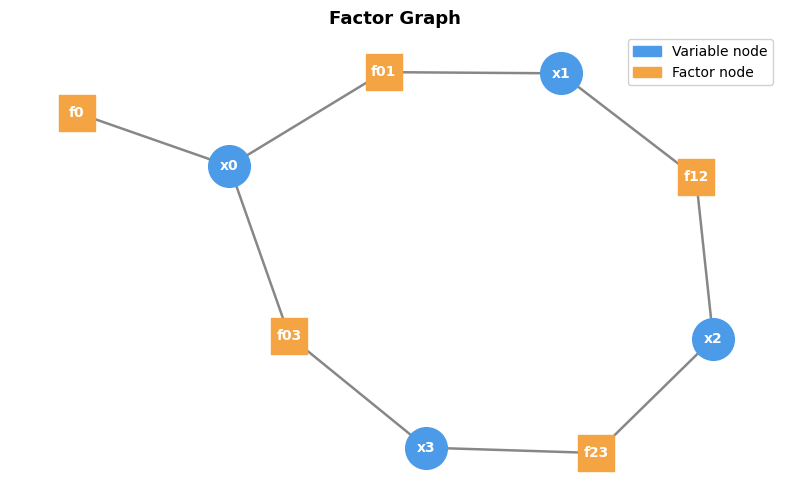

In [13]:
# 4 VARIABLE ISING MODEL WITH A LOOP

J = 0.8
def ising(a, b, J=J):
    s_a = 2 * a - 1  # map {0,1} -> {-1,+1}
    s_b = 2 * b - 1
    return np.exp(J * s_a * s_b)

def unary_bias(a, h=0.3):
    # Slight bias toward x=1
    return np.exp(h * (2 * a - 1))


factors01 = [
    ([0, 1], ising),
    ([1, 2], ising),
    ([2, 3], ising),
    ([0, 3], ising),        # creates a loop
    ([0],    unary_bias),   # unary factor on x0
]

graph01 = TrueGraph(n=4, factors=factors01, alphabet_size=2)

# sample 
n = 500
print(f"Sampling {n} samples via Gibbs...")
samples01 = graph01.sample(nsamples = n, n_burnin = 500, thinning = 5, seed = 0)
print(f"  Shape: {samples01.shape}")
print(f"  Marginals (P(x_i=1)): {samples01.mean(axis=0).round(3)}")

# Visualize
fig, ax = graph01.display_graph(
    var_names=["x0", "x1", "x2", "x3"],
    factor_labels=["f01", "f12", "f23", "f03", "f0"],
    seed=7,
)
plt.savefig("factor_graph.png", dpi=150, bbox_inches="tight")
print("  Graph saved to factor_graph.png")
plt.show()

100%|██████████████████████████████████████| 1000/1000 [00:01<00:00, 603.79it/s]


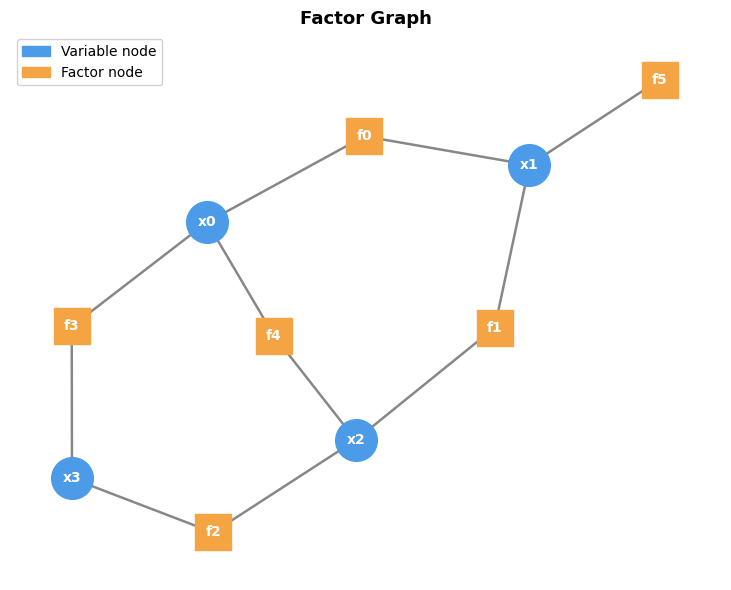

In [14]:
# 4 VARIABLE ISING CYCLE + DIAGONAL CHORD

def weak_ising(a, b):
    return ising(a, b, J = 0.5)

factors02 = [
    ([0,1], ising),
    ([1,2], ising),
    ([2,3], ising),
    ([0,3], ising),
    ([0,2], weak_ising),
    ([1],   unary_bias) 
]

graph02 = TrueGraph(n=4, factors=factors02, alphabet_size=2)

# sample
samples02 = graph02.sample(nsamples=1000, seed=111)

# visualize
fig, ax = graph02.display_graph(seed=7)
plt.show()

100%|████████████████████████████████████████| 200/200 [00:00<00:00, 749.53it/s]


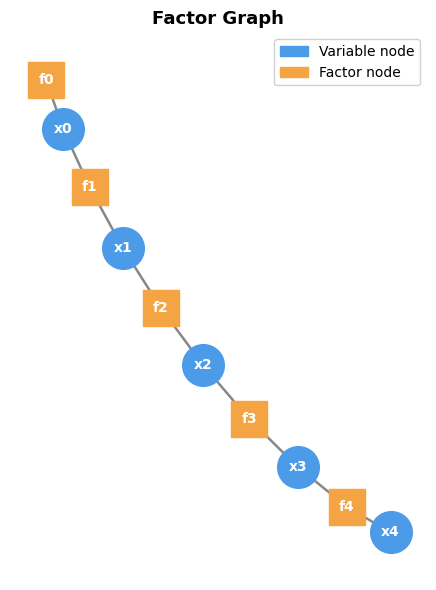

In [15]:
# 5 VARIABLE TREE - CHAIN

def binary_factor(x00, x01, x10, x11):
    def f(a, b):
        if a == 0 and b == 0: 
            return x00
        if a == 0 and b == 1:
            return x01
        if a == 1 and b == 0:
            return x10
        if a == 1 and b == 1:
            return x11
        raise ValueError("a and b must be in {0,1}")
    return f

def unary_factor(x0, x1):
    def f(a):
        if a == 0:
            return x0
        if a == 1:
            return x1
        raise ValueError("a must be in {0,1}")
    return f
            

transition_factor = binary_factor(1, 7, 3, 5)

factors03 = [
    ([0], unary_factor(5,2)),
    ([0,1], transition_factor),
    ([1,2], transition_factor),
    ([2,3], transition_factor),
    ([3,4], transition_factor)
]

graph03 = TrueGraph(n=5, factors=factors03, alphabet_size=2)
samples03 = graph03.sample(nsamples=200, seed=333)

fig, ax = graph03.display_graph(seed=7)
plt.show()

100%|████████████████████████████████████████| 300/300 [00:00<00:00, 785.74it/s]


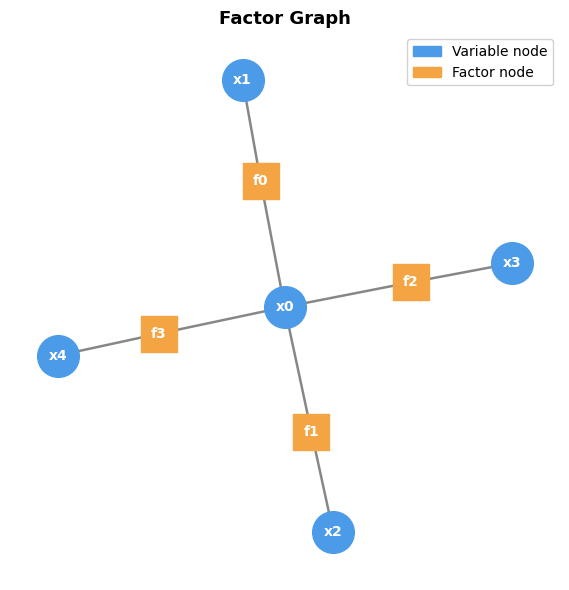

In [16]:
# 5 VARIABLE TREE - STAR

rng = np.random.default_rng(seed=1234)

def random_factor(rng):
    r = rng.uniform(size=4)
    return binary_factor(r[0], r[1], r[2], r[3])

factors04 = [
    ([0,1], random_factor(rng)),
    ([0,2], random_factor(rng)),
    ([0,3], random_factor(rng)),
    ([0,4], random_factor(rng)),
]

graph04 = TrueGraph(n=5, factors=factors04, alphabet_size=2)
samples04 = graph04.sample(nsamples=300, seed=444)

fig, ax = graph04.display_graph(seed=7)
plt.show()

100%|███████████████████████████████████████| 500/500 [00:00<00:00, 1016.72it/s]


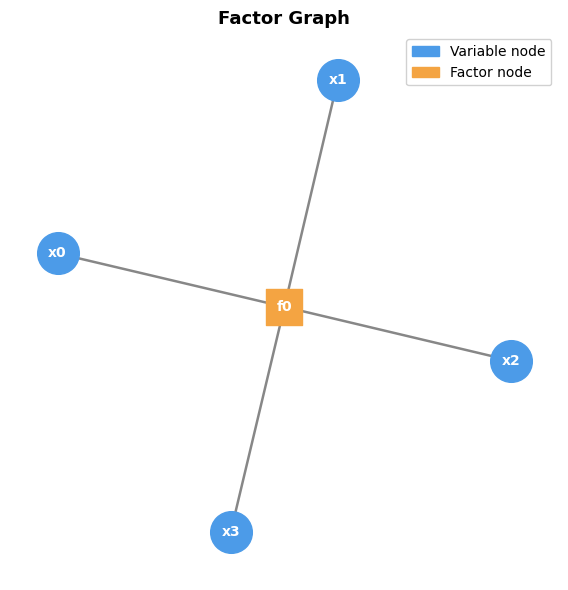

In [17]:
# SINGLE HIGH ORDER FACTOR

rng = np.random.default_rng(seed=314)

single_table = rng.uniform(size=16)

def single_factor(a, b, c, d, tbl=single_table):
    idx = 8 * a + 4 * b + 2 * c + d
    return tbl[idx]

factors05 = [
    ([0,1,2,3], single_factor)
]

graph05 = TrueGraph(n=4, factors=factors05, alphabet_size=2)
samples05 = graph05.sample(nsamples=500, seed=555)

fig, ax = graph05.display_graph(seed=7)
plt.show()

100%|████████████████████████████████████████| 600/600 [00:01<00:00, 380.75it/s]


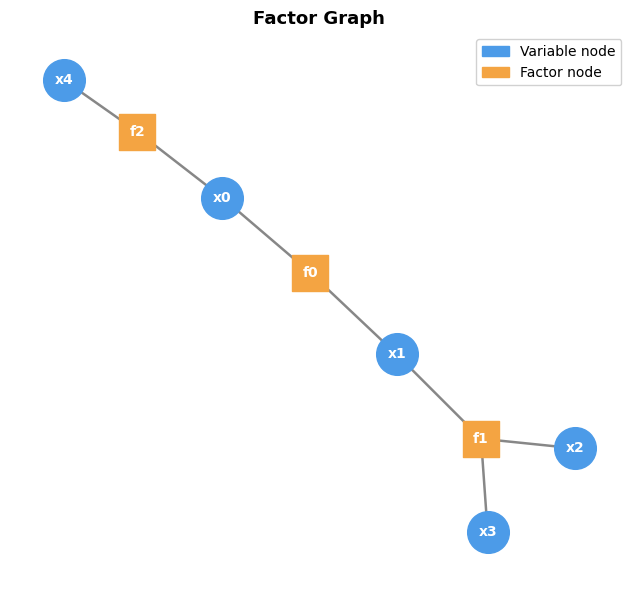

In [18]:
# MIXED STRUCTURE

def f06_1(a, b):
    tbl = np.array([
        [1,8,2],
        [4,2,8],
        [0,3,5]
    ])
    return tbl[a][b]

def f06_2(a, b, c):
    logits_ab = np.array([
        [-2,0,2],
        [0,6,8],
        [-1,4,2]
    ])
    c_temp = [1,2,0.2]
    temp = c_temp[c]
    vals = np.exp(logits_ab / temp) / np.sum(np.exp(logits_ab / temp), axis=1, keepdims=True)
    return vals[a,b]

def f06_3(a, b):
    tbl = np.array([
        [5,9,0],
        [1,3,7],
        [6,1,3]
    ])
    return tbl[a,b]

factors06 = [
    ([0,1], f06_1),
    ([1,2,3], f06_2),
    ([0,4], f06_3)
]

graph06 = TrueGraph(n=5, factors=factors06, alphabet_size=3)
samples06 = graph06.sample(nsamples=600, seed=666)

fig, ax = graph06.display_graph(seed=7)
plt.show()

100%|████████████████████████████████████████| 500/500 [00:00<00:00, 595.64it/s]


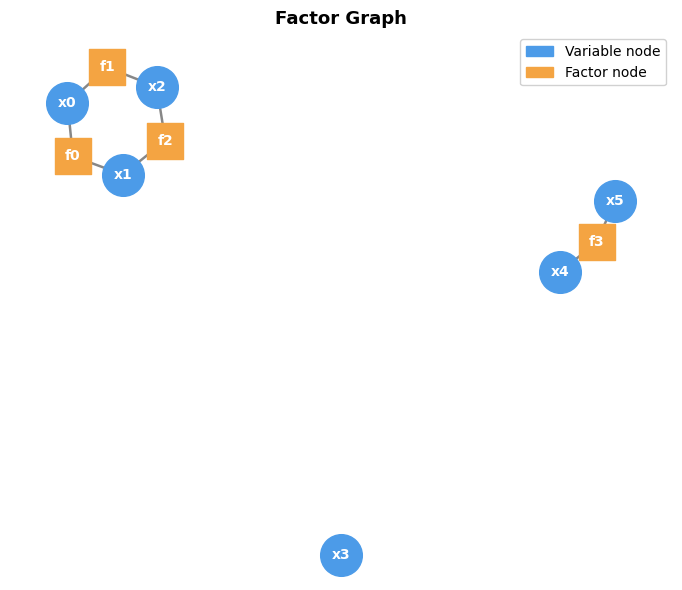

In [19]:
# DISCONNECTED

def f07_1(a, b):
    tbl = np.array([
        [1,6],
        [3,1]
    ])
    return tbl[a,b]

def f07_2(a, b):
    tbl = np.array([
        [4,1],
        [2,5]
    ])
    return tbl[a,b]

def f07_3(a, b):
    tbl = np.array([
        [5,3],
        [2,6]
    ])
    return tbl[a,b]

def f07_4(a, b):
    tbl = np.array([
        [1,5],
        [3,2]
    ])
    return tbl[a,b]

factors07 = [
    ([0,1], f07_1),
    ([0,2], f07_2),
    ([1,2], f07_3),
    ([4,5], f07_4)
]

graph07 = TrueGraph(n=6, factors=factors07, alphabet_size=2)
samples07 = graph07.sample(nsamples=500, seed=777)

fig, ax = graph07.display_graph(seed=7)
plt.show()

100%|████████████████████████████████████████| 500/500 [00:02<00:00, 243.73it/s]


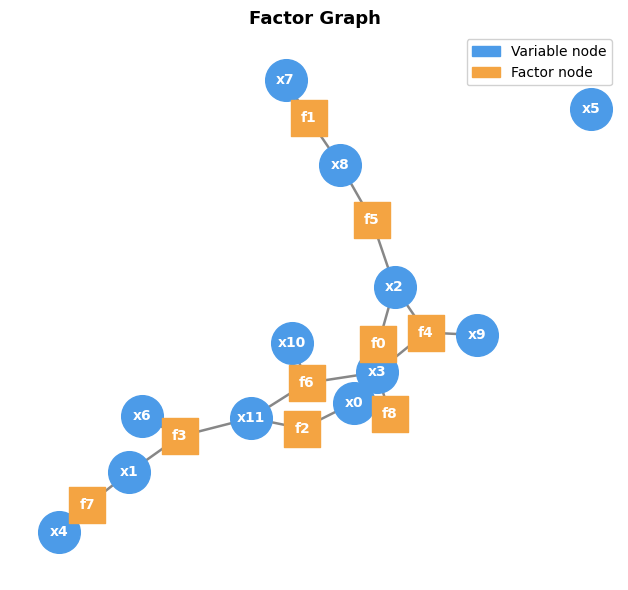

In [20]:
# LARGE GRAPH WITH RANDOM SPARSE STRUCTURE

rng = np.random.default_rng(seed=507)
n_vars_08 = 12
n_factors_08 = 9

factors08 = []
for i in range(n_factors_08):
    size = rng.choice([2,3])
    scope = rng.integers(low=0, high=n_vars_08, size=size)
    if size == 2:
        def f(a, b):
            tbl = np.array([
                [2,5],
                [5,2]
            ])
            return tbl[a,b]
    if size == 3:
        def f(a, b, c):
            if a == 0:
                tbl = np.array([
                    [3,3],
                    [4,3]
                ])
            else:
                tbl = np.array([
                    [1,10],
                    [10,1]
                ])
            return tbl[b,c]
    factors08.append((scope, f))

graph08 = TrueGraph(n=n_vars_08, factors=factors08, alphabet_size=2)
samples08 = graph08.sample(nsamples=500, seed=888)

fig, ax = graph08.display_graph(seed=7)
plt.show()

100%|████████████████████████████████████████| 400/400 [00:00<00:00, 498.89it/s]


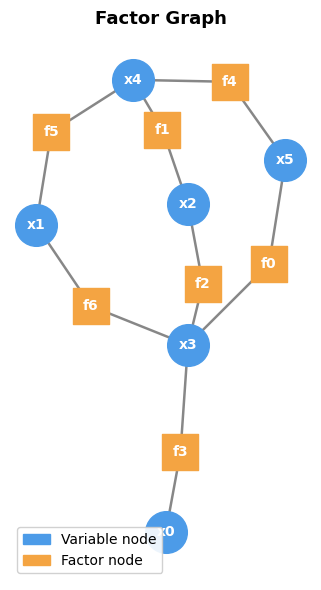

In [21]:
# STRONG INTERACTIONS

def f09_1(a,b):
    tbl = np.array([
        [8,1],
        [2,7]
    ])
    return tbl[a,b]

def f09_2(a,b):
    tbl = np.array([
        [1,1],
        [1,9]
    ])
    return tbl[a,b]

factors09 = [
    ([3,5], f09_2),
    ([2,4], f09_2),
    ([2,3], f09_1),
    ([0,3], f09_2),
    ([4,5], f09_2),
    ([1,4], f09_2),
    ([1,3], f09_1)
]

graph09 = TrueGraph(n=6, factors=factors09, alphabet_size=2)
samples09 = graph09.sample(nsamples=400, seed=999)

fig, ax = graph09.display_graph(seed=7)
plt.show()

100%|████████████████████████████████████████| 400/400 [00:00<00:00, 519.55it/s]


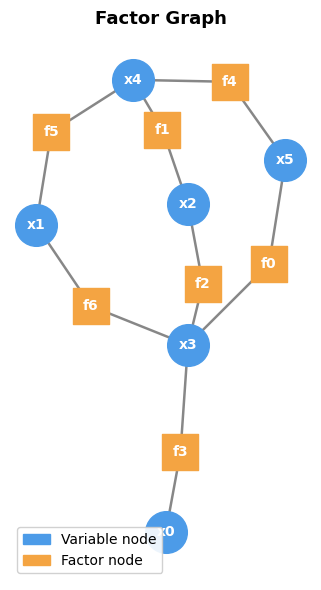

In [22]:
# WEAK INTERACTIONS

def f10_1(a,b):
    tbl = np.array([
        [5,4],
        [4.2,4.8]
    ])
    return tbl[a,b]

def f10_2(a,b):
    tbl = np.array([
        [3,3],
        [3,4.5]
    ])
    return tbl[a,b]

factors10 = [
    ([3,5], f10_2),
    ([2,4], f10_2),
    ([2,3], f10_1),
    ([0,3], f10_2),
    ([4,5], f10_2),
    ([1,4], f10_2),
    ([1,3], f10_1)
]

graph10 = TrueGraph(n=6, factors=factors10, alphabet_size=2)
samples10 = graph10.sample(nsamples=400, seed=999)

fig, ax = graph10.display_graph(seed=7)
plt.show()

In [25]:
graph_list = [
    graph01, 
    graph02,
    graph03,
    graph04,
    graph05,
    graph06,
    graph07,
    graph08,
    graph09,
    graph10
]

sample_list = [
    samples01,
    samples02,
    samples03,
    samples04,
    samples05,
    samples06,
    samples07,
    samples08,
    samples09,
    samples10
]

# Random Graphs

In [26]:
def random_potential_table(alphabet_size, rng, size=2, strength=1.0, symmetric=False):
    log_table = rng.normal(0.0, strength, size=tuple([alphabet_size]*size))
    # log_table = rng.normal(0.0, strength, size=(alphabet_size, alphabet_size))
    if symmetric and size == 2:
        log_table = (log_table + log_table.T) / 2.0
    table = np.exp(log_table)
    return table

def make_factor(tbl):
    def f(*args):
        return tbl[tuple(args)]
    return f

def generate_random_tree(n, alphabet_size, rng, strength=1.0, symmetric=False):
    sd = int(rng.integers(10000))
    rand_tree = nx.random_tree(n, seed=sd)
    edge_list = list(rand_tree.edges)
    potential_dict = {}
    for edge in edge_list:
        potential_dict[edge] = random_potential_table(alphabet_size, rng, size=2)
    factor_list = []
    for endpts, tbl in potential_dict.items():
        f = make_factor(tbl)
        factor_list.append((endpts, f))
    return TrueGraph(n, factor_list, alphabet_size)

In [27]:
def is_subset(scope, existing_scopes):
    s = set(scope)
    for e in existing_scopes:
        if s.issubset(e):
            return True
    return False

def generate_random_graph(n, alphabet_size, rng, n_factors=None, max_factor_size=3, strength=1.0):
    if n_factors is None:
        n_factors = rng.poisson(lam=n)
    factor_list = []
    scopes = []
    attempts = 0
    max_attempts = 10 * n_factors
    while len(scopes) < n_factors and attempts < max_attempts:
        attempts += 1
        # sample factor size (at least 2)
        size = int(rng.integers(2, max_factor_size + 1))
        # sample variables without replacement
        scope = tuple(sorted(rng.choice(n, size=size, replace=False)))
        # enforce: no subset condition
        if is_subset(scope, scopes):
            continue
        # also avoid exact duplicates
        if scope in scopes:
            continue
        scopes.append(set(scope))
        # generate potential table
        tbl = random_potential_table(alphabet_size, rng, size=size, strength=strength)
        f = make_factor(tbl)
        factor_list.append((scope, f))
    if len(scopes) < n_factors:
        print(f"Warning: only generated {len(scopes)} factors (target was {n_factors})")
    return TrueGraph(n, factor_list, alphabet_size)

In [28]:
rng = np.random.default_rng(seed=414)
random_tree = generate_random_tree(10, 2, rng)
random_graph = generate_random_graph(10, 2, rng)

(<Figure size 800x600 with 1 Axes>, <Axes: title={'center': 'Factor Graph'}>)

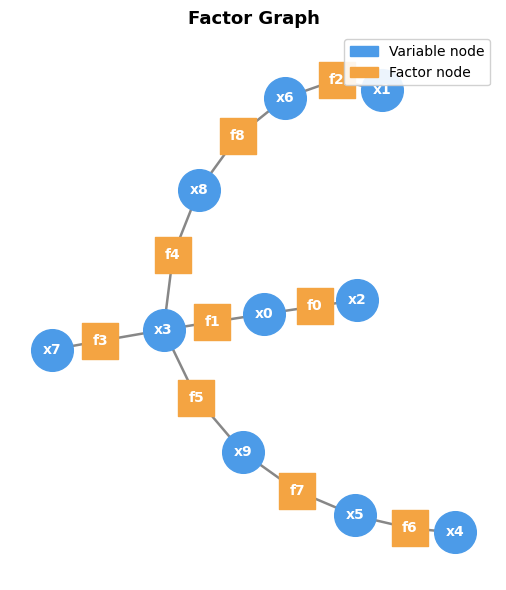

In [29]:
random_tree.display_graph(seed=1)

(<Figure size 800x600 with 1 Axes>, <Axes: title={'center': 'Factor Graph'}>)

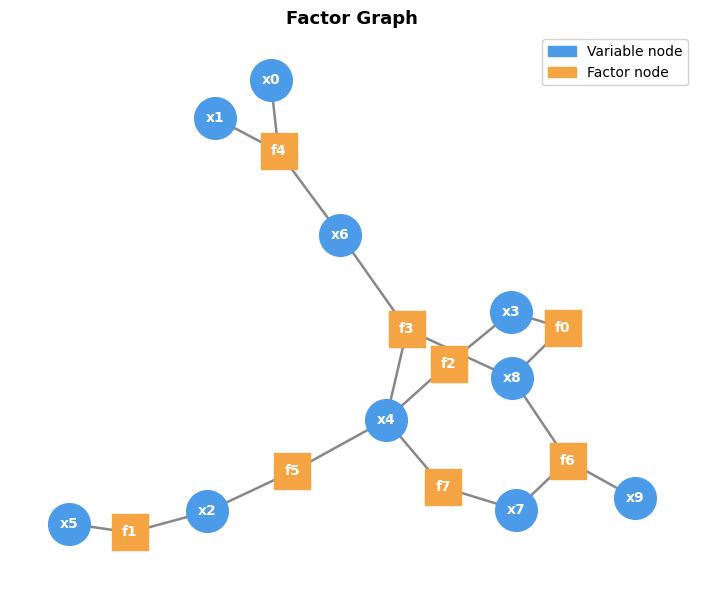

In [30]:
random_graph.display_graph(seed=1)

# Chow-Liu Solver

In [31]:
# Copied from Chow-Liu project
def kruskal_max_spanning_tree(weights):
    """Compute a maximum spanning tree using Kruskal's algorithm.

    Parameters
    ----------
    weights : np.ndarray of shape (n, n)
        Symmetric edge-weight matrix (here: MI estimates).

    Returns
    -------
    list[tuple[int, int]]
        `n-1` edges of a maximum spanning tree.
    """
    n = weights.shape[0]
    edges = [(weights[i, j], i, j) for i in range(n) for j in range(i + 1, n)]
    edges.sort(key=lambda t: t[0], reverse=True)

    parent = list(range(n))
    rank = [0] * n

    def find(x):
        """Find set representative with path compression."""
        while parent[x] != x:
            parent[x] = parent[parent[x]]
            x = parent[x]
        return x

    def union(a, b):
        """Union-by-rank; return True iff a merge happened."""
        ra, rb = find(a), find(b)
        if ra == rb:
            return False
        if rank[ra] < rank[rb]:
            parent[ra] = rb
        elif rank[ra] > rank[rb]:
            parent[rb] = ra
        else:
            parent[rb] = ra
            rank[ra] += 1
        return True

    tree = []
    for _, u, v in edges:
        if union(u, v):
            tree.append((u, v))
            if len(tree) == n - 1:
                break
    return tree



def empirical_pairwise_mi(samples, alphabet_size, eps=1e-12):
    """Estimate pairwise mutual information from samples.

    Parameters
    ----------
    samples : np.ndarray of shape (m, n)
        Binary data matrix with `m` samples and `n` variables.
    eps : float, default=1e-12
        Small constant for numerical stability in log-ratio terms.

    Returns
    -------
    np.ndarray of shape (n, n)
        Symmetric MI estimate matrix with zeros on the diagonal.

    Notes
    -----
    Implement using empirical marginals/joints:
    - `p_i(a)`, `p_j(b)`, `p_ij(a,b)`
    - `MI(i,j) = sum_{a,b} p_ij(a,b) log(p_ij(a,b)/(p_i(a)p_j(b)))`
    """
    m, n = samples.shape
    mi = np.zeros((n,n))
    # off diagonals (mutual information)
    for x in range(n):
        for y in range(x+1,n):
            mi_xy = 0
            for i in range(alphabet_size):
                for j in range(alphabet_size):
                    pxy = np.mean((samples[:,x] == i) & (samples[:,y] == j))
                    px = np.mean((samples[:,x] == i))
                    py = np.mean((samples[:,y] == j))
                    mi_xy += pxy * np.log((pxy + eps) / (px * py + eps))
            mi[x,y] = mi_xy
            mi[y,x] = mi_xy
    return mi

In [32]:
def chow_liu(samples, alphabet_size, alpha=1):
    nsamp, nvar = samples.shape
    # Step 1: MI + MST
    mi = empirical_pairwise_mi(samples, alphabet_size)
    mst = kruskal_max_spanning_tree(mi)
    # Step 2: build adjacency
    adj = {i: [] for i in range(nvar)}
    for i, j in mst:
        adj[i].append(j)
        adj[j].append(i)
    # Step 3: pick root and orient tree
    root = 0
    parent = {root: None}
    order = [root]
    # BFS to orient tree
    queue = [root]
    while queue:
        u = queue.pop(0)
        for v in adj[u]:
            if v not in parent:
                parent[v] = u
                queue.append(v)
                order.append(v)
    factors = []
    # Step 4: root marginal
    p_root = np.zeros(alphabet_size)
    for a in range(alphabet_size):
        count = np.sum(samples[:, root] == a)
        p_root[a] = (count + alpha) / (nsamp + alpha * alphabet_size)
    factors.append(((root,), make_factor(p_root)))
    # Step 5: conditional tables
    for child in order[1:]:
        par = parent[child]
        joint = np.zeros((alphabet_size, alphabet_size))
        for a in range(alphabet_size):
            for b in range(alphabet_size):
                count = np.sum((samples[:, par] == a) & (samples[:, child] == b))
                joint[a, b] = count + alpha
        # normalize rows
        cond = joint / joint.sum(axis=1, keepdims=True)
        factors.append(((par, child), make_factor(cond)))
    return TrueGraph(nvar, factors, alphabet_size)

# Learn

In [248]:
def plot_losses(losses, save_fig = False, path = ""):
    ep = 1 + np.arange(len(losses['Total']))
    plt.plot(ep, losses['Total'], label="Total")
    plt.plot(ep, losses["Main"], label="NCE")
    plt.plot(ep, losses["Reg"], label="Regularization")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.legend()
    if save_fig:
        plt.savefig(path)
    plt.show()

def plot_diagnostics(diagnostics, save_fig=False, path=""):
    ep = 1 + np.arange(len(diagnostics['n_active_factors']))
    fig, axs = plt.subplots((2,1))
    axs[0].plot(ep, diagnostics["avg_factor_size"])
    axs[0].set_title("Average Factor Size")
    axs[1].plot(ep, diagnostics["n_active_factors"])
    axs[1].set_title("Number Active Factors")
    if save_fig:
        plt.savefig(path)
    plt.show()

def plot_diagnostics(diagnostics, save_fig=False, path=None):
    ep = 1 + np.arange(len(diagnostics['n_active_factors']))
    fig, axs = plt.subplots(1, 2, figsize=(10, 5))
    # Average factor size
    axs[0].plot(ep, diagnostics["avg_factor_size"])
    axs[0].set_title("Average Factor Size")
    axs[0].set_xlabel("Epoch")
    axs[0].set_ylabel("Size")
    # Number of active factors
    axs[1].plot(ep, diagnostics["n_active_factors"])
    axs[1].set_title("Number of Active Factors")
    axs[1].set_xlabel("Epoch")
    axs[1].set_ylabel("Count")
    plt.tight_layout()
    if save_fig and path:
        plt.savefig(path)
    plt.show()

In [251]:
def test_learner(graph, samples, K, hidden_dims=(16,16), max_factor_size=None, shared_mlp=False, 
                 epochs=100, lr=1e-3, l_mask=0.1, l_weight=0.01, l_mlp=0.01, l_bp=0.01, schedule=False,
                 seed=123, verbose=True, plot=True):
    alph_size = graph.alphabet_sizes[0]
    n_vars = graph.n
    ng = IndependentMarginals(samples, alphabet_size=alph_size, alpha=1, seed=456)
    learner = FactorGraphLearner(n_vars=n_vars, alphabet_size=alph_size, K=K, noise_generator=ng, 
                                 hidden_dims=hidden_dims, max_factor_size=max_factor_size, shared_mlp=shared_mlp, seed=seed)
    ls, diags = learner.train(samples, n_epochs=epochs, lr=lr, 
                              lambda_mask=l_mask, lambda_weight=l_weight, lambda_mlp_l2=l_mlp, lambda_bp=l_bp, penalty_schedule=schedule,
                              log_every=10, verbose=verbose)
    if plot:
        plot_losses(ls)
        plot_diagnostics(diags)
    return learner, ls, diags

In [252]:
# EXAMPLE = 10

# GRAPH = graph_list[EXAMPLE-1]
# SAMPLES = sample_list[EXAMPLE-1]

GRAPH = random_tree
SAMPLES = GRAPH.sample(nsamples=500, seed=12)

100%|████████████████████████████████████████| 500/500 [00:01<00:00, 387.13it/s]


Epoch   10/100  loss=0.8072  main=0.8070  reg=0.0001
Epoch   20/100  loss=0.7008  main=0.6763  reg=0.0245
Epoch   30/100  loss=0.7085  main=0.6715  reg=0.0370
Epoch   40/100  loss=0.6947  main=0.6506  reg=0.0441
Epoch   50/100  loss=0.6959  main=0.6455  reg=0.0504
Epoch   60/100  loss=0.7008  main=0.6554  reg=0.0454
Epoch   70/100  loss=0.7089  main=0.6673  reg=0.0416
Epoch   80/100  loss=0.7027  main=0.6654  reg=0.0373
Epoch   90/100  loss=0.6973  main=0.6630  reg=0.0342
Epoch  100/100  loss=0.6858  main=0.6546  reg=0.0312


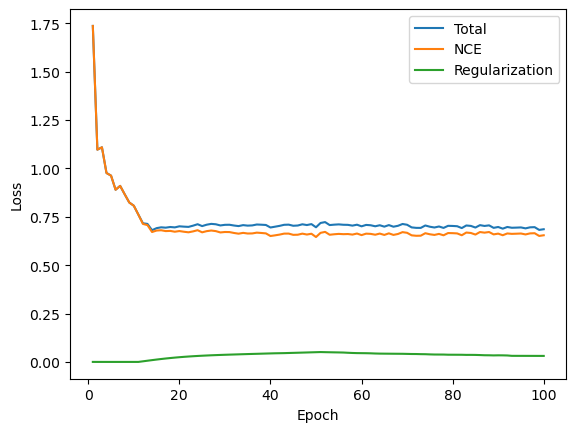

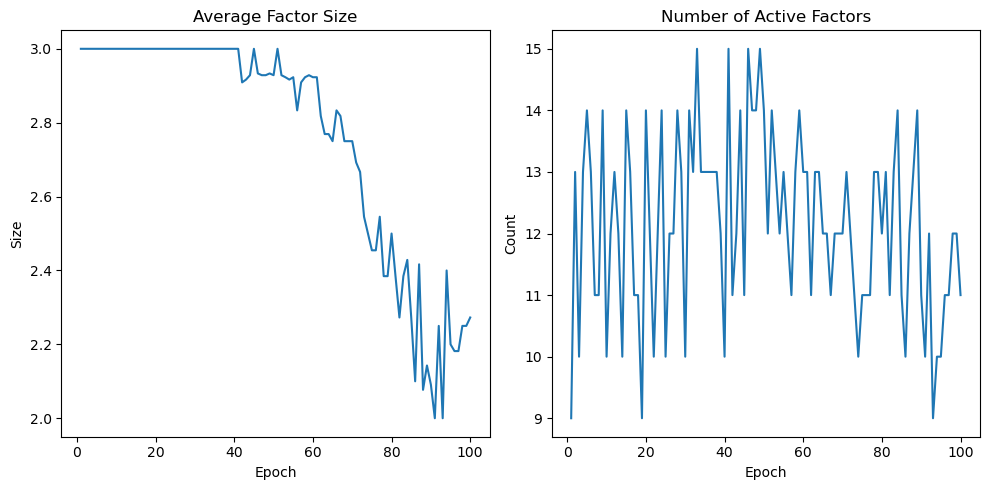

In [259]:
lrn, final_loss, masks = test_learner(GRAPH, SAMPLES, K=15, hidden_dims=(32,8), lr=0.01, max_factor_size=3,
                                      epochs=100, l_mask=0.1, l_weight=0.01, l_bp=0.001, schedule=True)
# Good lambda defaults:
#    l_mask:   0.1
#    l_weight: 0.01
#    l_mlp:    0.01
#    l_bp:     0.001

In [260]:
kl_divergence(GRAPH, lrn)

0.038384683520938594

In [261]:
compare_graph(GRAPH, lrn)

=== GRAPH 1 FACTORS ===
[0, 2]
[0, 3]
[1, 6]
[3, 7]
[3, 8]
[3, 9]
[4, 5]
[5, 9]
[6, 8]

=== GRAPH 2 FACTORS ===
[1, 5, 8]
[2]
[5, 7]
[1]
[1, 3, 6]
[8, 9]
[2, 3, 6]
[0, 9]
[4, 5]
[6, 8]
[7, 8, 9]
[0, 1, 6]


In [262]:
edge_metrics(GRAPH, lrn), factor_metrics(GRAPH, lrn), structural_hamming_distance(GRAPH, lrn)

({'precision': 0.1764705881314879,
  'recall': 0.3333333329629629,
  'tp': 3,
  'fp': 14,
  'fn': 6},
 {'precision': 0.16666666652777776,
  'recall': 0.2222222219753086,
  'tp': 2,
  'fp': 10,
  'fn': 7},
 20)

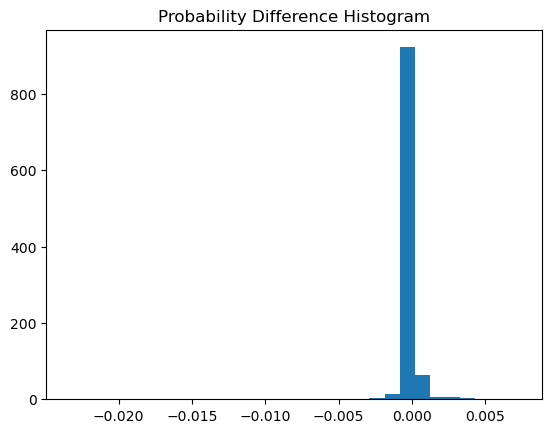

In [263]:
prob_diff_hist(GRAPH, lrn)

Chow-Liu Diagnostics=======
KL Divergence: 0.03466667377341158
Structural Hamming Distance: 10
=== GRAPH 1 FACTORS ===
[0, 2]
[0, 3]
[1, 6]
[3, 7]
[3, 8]
[3, 9]
[4, 5]
[5, 9]
[6, 8]

=== GRAPH 2 FACTORS ===
[0]
[0, 5]
[5, 9]
[7, 9]
[3, 9]
[1, 9]
[1, 6]
[6, 8]
[2, 6]
[4, 6]
Edge Metrics:
{'precision': 0.4444444439506172, 'recall': 0.4444444439506172, 'tp': 4, 'fp': 5, 'fn': 5}
Factor Metrics:
{'precision': 0.3999999996, 'recall': 0.4444444439506172, 'tp': 4, 'fp': 6, 'fn': 5}


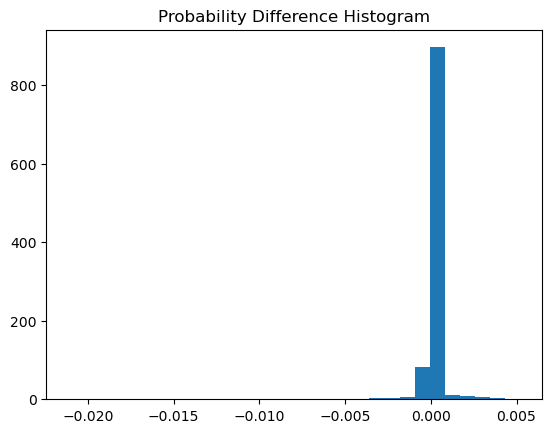

In [265]:
chow_liu_graph = chow_liu(SAMPLES, GRAPH.alphabet_sizes[0])

print("Chow-Liu Diagnostics=======")

print(f"KL Divergence: {kl_divergence(GRAPH, chow_liu_graph)}") 
print(f"Structural Hamming Distance: {structural_hamming_distance(GRAPH, chow_liu_graph)}")
compare_graph(GRAPH, chow_liu_graph)
print("Edge Metrics:")
print(edge_metrics(GRAPH, chow_liu_graph))
print("Factor Metrics:")
print(factor_metrics(GRAPH, chow_liu_graph))
prob_diff_hist(GRAPH, chow_liu_graph)

In [269]:
print(f"MLE KL Divergence: {kl_divergence_mle(GRAPH, SAMPLES, alpha=0.1)}")

MLE KL Divergence: 0.2946166317659705


In [272]:
print(f"Optimal MLE KL Divergence: {kl_mle_optimal(GRAPH, SAMPLES)}")

Optimal MLE KL Divergence: 0.2946166317659705


In [267]:
help(FactorGraphLearner.train)

Help on function train in module __main__:

train(self, data, n_epochs=1000, batch_size=128, lr=0.001, lambda_mask=0.1, lambda_weight=0.1, lambda_mlp_l2=0.01, lambda_bp=0.01, penalty_schedule=False, noise_ratio=1, device='cpu', verbose=True, log_every=50)



Other ideas
- figure out a better way of comparing learned graphs and probability distributions (Monte Carlo KL??)
- Test a suite of regularization values to see loss and KL divergence results

# Experiments - Graph Creation

In [ ]:
# tree graph
# graph with loops but binary factors
# graph with factor having 3+ variables
# disconnected graph
# random graph

# Experiment 1: Effect of Regularization

# Experiment 2: Comparison to Chow-Liu

# Experiment 3: Stability wrt Random Initializations

# Experiment 4: Scalability

# Experiment 5: Dependence on Sample Size